# Evaluation

We compare our from-scratch Transformer encoder against the TF-IDF baseline and a fine-tuned DistilBERT on held-out MS MARCO test queries, then demonstrate retrieval over the book corpus.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from baseline import TfidfSearchEngine, load_json
from search import NeuralSearchEngine, load_encoder, get_device
from evaluate import evaluate_engine, summarize, build_eval_corpus
from corpus import build_book_corpus

TRAIN_PATH = PROJECT_ROOT / "data/pairs/train.json"
TEST_PATH = PROJECT_ROOT / "data/pairs/test.json"
CHECKPOINT_DIR = PROJECT_ROOT / "checkpoints"

## 1. Evaluation corpus

Each test query is searched against its own positive passage plus a large pool of training passages acting as distractors. Ranking the correct passage among thousands of others is much closer to real retrieval than ranking it against only the other test positives.

In [2]:
MAX_EVAL_SAMPLES = 500
N_DISTRACTORS = 5000

train_data = load_json(TRAIN_PATH)
test_data = load_json(TEST_PATH)[:MAX_EVAL_SAMPLES]

documents, metadata = build_eval_corpus(test_data, train_data, N_DISTRACTORS)
print(f"Test queries: {len(test_data)}")
print(f"Corpus documents: {len(documents)}")

Test queries: 500
Corpus documents: 5500


## 2. TF-IDF baseline

In [3]:
tfidf = TfidfSearchEngine()
tfidf.fit(documents, metadata)
tfidf_metrics = summarize(evaluate_engine(tfidf, test_data, top_k=10))
tfidf_metrics

{'Recall@1': 0.684,
 'Recall@5': 0.872,
 'Recall@10': 0.908,
 'MRR': 0.7644619048539039}

## 3. Neural encoders

We evaluate the InfoNCE checkpoint of each architecture: our main from-scratch Transformer and the fine-tuned DistilBERT.

In [4]:
device = get_device()
checkpoints = {
    "Transformer (scratch)": CHECKPOINT_DIR / "encoder_tfscratch_infonce_final.pt",
    "DistilBERT": CHECKPOINT_DIR / "encoder_infonce_final.pt",
}

neural_metrics = {}
for name, path in checkpoints.items():
    if not path.exists():
        print(f"skip {name}: {path.name} not found")
        continue
    model = load_encoder(str(path), device=device)
    engine = NeuralSearchEngine(model, device=device)
    engine.fit(documents, metadata)
    neural_metrics[name] = summarize(evaluate_engine(engine, test_data, top_k=10))
    print(name, neural_metrics[name])

Transformer (scratch) {'Recall@1': 0.4, 'Recall@5': 0.55, 'Recall@10': 0.622, 'MRR': 0.46447698450498254}


DistilBERT {'Recall@1': 0.806, 'Recall@5': 0.94, 'Recall@10': 0.966, 'MRR': 0.864872222256222}


## 4. Comparison

In [5]:
metric_keys = ["Recall@1", "Recall@5", "Recall@10", "MRR"]
all_results = {"TF-IDF": tfidf_metrics, **neural_metrics}

header = f"{'Metric':<12}" + "".join(f"{name:>12}" for name in all_results)
print(header)
print("-" * len(header))
for key in metric_keys:
    print(f"{key:<12}" + "".join(f"{all_results[name][key]:>12.4f}" for name in all_results))

Metric            TF-IDFTransformer (scratch)  DistilBERT
---------------------------------------------------------
Recall@1          0.6840      0.4000      0.8060
Recall@5          0.8720      0.5500      0.9400
Recall@10         0.9080      0.6220      0.9660
MRR               0.7645      0.4645      0.8649


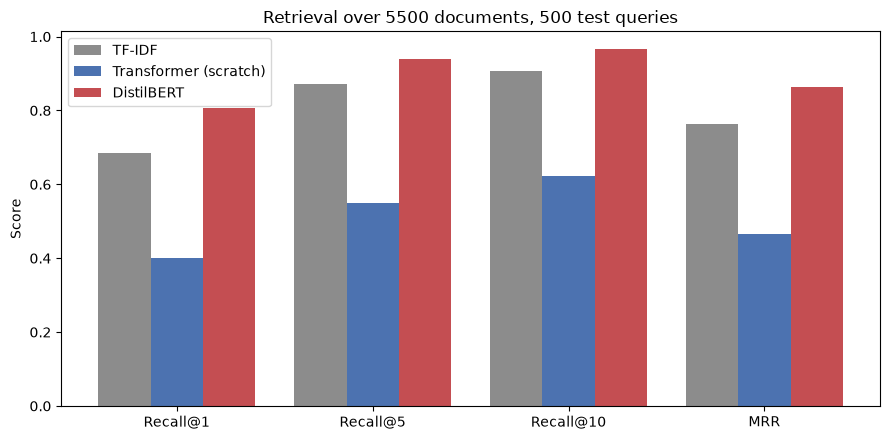

In [6]:
names = list(all_results)
x = np.arange(len(metric_keys))
width = 0.8 / len(names)
colors = ["#8C8C8C", "#4C72B0", "#C44E52", "#55A868"]

fig, ax = plt.subplots(figsize=(9, 4.5))
for i, name in enumerate(names):
    vals = [all_results[name][k] for k in metric_keys]
    ax.bar(x + i * width, vals, width, label=name, color=colors[i % len(colors)])

ax.set_xticks(x + width * (len(names) - 1) / 2)
ax.set_xticklabels(metric_keys)
ax.set_ylabel("Score")
ax.set_title(f"Retrieval over {len(documents)} documents, {len(test_data)} test queries")
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=120)
plt.show()

## 5. Book corpus demo

Finally we search 200–300 word passages from the book with the strongest neural encoder and the TF-IDF baseline side by side.

In [7]:
book_docs, book_meta = build_book_corpus()
print(f"Book chunks: {len(book_docs)}")

book_tfidf = TfidfSearchEngine()
book_tfidf.fit(book_docs, book_meta)

main_name = "Transformer (scratch)"
book_neural = None
if main_name in checkpoints and checkpoints[main_name].exists():
    model = load_encoder(str(checkpoints[main_name]), device=device)
    book_neural = NeuralSearchEngine(model, device=device)
    book_neural.fit(book_docs, book_meta)
    print(f"Neural engine: {main_name}")

Book chunks: 1119


Neural engine: Transformer (scratch)


In [8]:
def show(engine, query, top_k=3):
    for r in engine.search(query, top_k=top_k):
        text = " ".join(r["text"].split())
        print(f"  [{r['rank']}] score={r['score']:.3f}  {text[:160]}...")

queries = [
    "What is byte pair encoding?",
    "How does self-attention work in a transformer?",
    "What is the difference between precision and recall?",
    "What is perplexity in language modeling?",
    "What are word embeddings?",
]

for q in queries:
    print(f"\nQUERY: {q}")
    print(" TF-IDF:")
    show(book_tfidf, q)
    if book_neural:
        print(f" Neural ({main_name}):")
        show(book_neural, q)


QUERY: What is byte pair encoding?
 TF-IDF:
  [1] score=0.445  UTF-8 is thus a variable-length encoding.variable-length encoding For some characters (the ﬁrst 127 code points, i.e. the set of ASCII characters), UTF-8 encode...
  [2] score=0.213  UTF-8 has a number of advantages. It’s relatively efﬁcient, using fewer bytes for commonly-encountered characters, it doesn’t use zero bytes (except when litera...
  [3] score=0.210  In the graph, the encoding efﬁciency of BPE plateaus early due to exhausting the valuable whitespacedelimited words in the training data. In fact, it is bounded...
 Neural (Transformer (scratch)):
  [1] score=0.281  6.6.4 Backward differentiation on computation graphs The importance of the computation graph comes from the backward pass, which is used to compute the derivati...
  [2] score=0.275  UTF-8 is thus a variable-length encoding.variable-length encoding For some characters (the ﬁrst 127 code points, i.e. the set of ASCII characters), UTF-8 encode...
  [3] s